#Definition af CNNTRansformer klasse 

- num_classes : Number of classes we want to classify prediction in. In our case it is binary (True / False)

- in_channels : Number of columns in dataset, or number of culumns the model should analyze. In our case it is all columns, expect for timestep. According to chat, we don't need timestep to make preidiction. 

- embed_dim : size of feature vector used by transformer. if training is unstable, reduce to 64, if model overfits, use 256. Embed_dim must be divisable by num_heads (FInd ud af specifikt h)

- num_heads : Number of attention heads in transformers mult-head attention layer. 

- num_layers : Number of transformer layers (?)

- mlp_dim : Size of feedforward inside each transformor layer (Hvorfor er det 256)

- dropout : Percentage of neurons we randomly turn off during each training step. 

#Definition af CNN feature extractor

- self.cnn = nn.Sequential()
    - order of inputs define which order each layer should execute in

- nn.Conv1d(in_channels, 32, kernel_size=3, stride=2, padding=1)
    - in_channels : Number of input features, so how many variables are in each timestep
    - 32 : Output channels. How many patterns the CNN will learn.
    - Kernel_size : Size of the filter
    - Stride : how many steps we move the filter
    - padding : how many 0 we add to the start and end of the input. Prevents the sequence from shrinking too much. 

- nn.BatchNorm1d(32)
    - Normalizes the activations 
    
- nn.ReLU(inplace=True)
    - Means we are using relu
    - Inplace : modifys the current tensor directly, instead of creating a whole new tensor. This saves memory. 

In [15]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

path = Path('datasets/EPIC/Scenario_1/EpicLog_Scenario 1_19_Oct_2018_14_44.csv')

# Load the CSV file
df = pd.read_csv(path)
df = df.drop(columns=['Timestamp'])
df

#print(df.dtypes[df.dtypes == "object"])

,Generation.GIED1.Measurement.Apparent,Generation.GIED1.Measurement.Frequency,Generation.GIED1.Measurement.L1_Current,Generation.GIED1.Measurement.L2_Current,Generation.GIED1.Measurement.L3_Current,Generation.GIED1.Measurement.Power_Factor,Generation.GIED1.Measurement.Reactive,Generation.GIED1.Measurement.Real,Generation.GIED1.Measurement.V1,Generation.GIED1.Measurement.V2,...,VSD3.ActualSpeed,VSD3.Current,VSD3.E_Stop,VSD3.Fault,VSD3.Ready,VSD3.Reset,VSD3.Start,VSD3.Start_Flag,VSD3.Stop,VSD3.Stop_Flag
0,697.888306,49.969997,2.850000,0.000000,0.000000,0.9467,-224.733871,660.692200,244.887680,243.250305,...,0.0,0.0,True,False,False,False,False,True,False,False
1,679.634338,49.972000,2.775000,0.000000,0.000000,0.9624,-184.314377,654.136719,244.902786,243.099411,...,0.0,0.0,True,False,False,False,False,True,False,False
2,661.887451,49.973999,2.700000,0.000000,0.000000,0.9644,-174.861435,638.381836,245.147980,243.001312,...,0.0,0.0,True,False,False,False,False,True,False,False
3,698.069397,49.973000,2.700000,0.000000,0.000000,0.9174,-230.927170,658.772644,244.932953,243.303146,...,0.0,0.0,True,False,False,False,False,True,False,False
4,698.069397,49.973000,2.700000,0.000000,0.000000,0.9174,-230.927170,658.772644,244.932953,243.303146,...,0.0,0.0,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,4853.671875,50.007999,6.825000,6.000000,6.374999,0.9665,-1209.578979,4691.523438,245.404526,243.627579,...,0.0,0.0,True,False,False,False,False,True,False,False
508,4351.724121,50.013000,6.674999,5.175000,5.625000,0.9599,-1205.776001,4177.623535,245.332886,243.631378,...,0.0,0.0,True,False,False,False,False,True,False,False
509,4949.759277,50.011997,8.400000,5.175000,6.224999,0.9631,-1208.745972,4767.545410,246.117599,244.031281,...,0.0,0.0,True,False,False,False,False,True,False,False
510,4409.999023,50.017998,7.499999,5.249999,4.575000,0.9555,-1189.695190,4214.095215,245.574310,244.185959,...,0.0,0.0,True,False,False,False,False,True,False,False


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoConfig, AutoModel

class CNNTransformer(nn.Module):
    def __init__(
        self,
        num_classes: int = 8,
        in_channels: int = df.shape[1],
        embed_dim: int = 128,
        #num_heads: int = 4, 
        #num_layers: int = 2,
        #mlp_dim: int = 256,
        #dropout: float = 0.1
    ):
        super().__init__()

        
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, embed_dim, kernel_size=5, padding=2),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Conv1d(embed_dim, 64, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv1d(32, in_channels, kernel_size=5, padding=2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        x_hat = self.decoder(z)
        x_hat = F.interpolate(x_hat, size=x.shape[-1], mode="linear", align_corners=False)
        return x_hat
    
    def transformer():
        config = AutoConfig.from_pretrained("bert-base-uncased")
        model = AutoModel.from_config(config) # random initialization, not pretrained weights

        print(model.config)

print("CNNTransformer model defined successfully.")

CNNTransformer model defined successfully.


In [ ]:
#Test vidreudviklng
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoConfig, AutoModel

class CNNTransformer(nn.Module):
    def __init__(
        self,
        in_channels: int,
        embed_dim: int = 768, #Skal marche bert base uncased hidden size
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            #Første convolutional lag
            #den ser på smp vinduer i tiddserien og lærer lokale/korte mønstre
            #Så vi går fra raw data af signaler og laver det til et lag af features/mønstre
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2),

            #Relu tilføjer non-linearity
            #Dette gør at modellen er i stand til at lærer komplekse mønstrer og ikke bruger en linær funktion til at forstå vores features 
            nn.ReLU(),

            #Halverer sekvens længden og sletter unødvendig støj(?) så sekvensen er nemmere at analuserer senere 
            #SÅ hvis længden er 256 før, bliver den til 128 efter
            nn.MaxPool1d(2),


            #Anden convlutional blok
            #Modellen bygger videre på de første features og lærer mere advencerede og langvarige mønstrer
            #efter anden pooling, bliver sekvens længden endy kortere, så f. eks. 128 bliver til 64
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),


            # Sidste convolutional blok, hvor vi faktisk danner et output. Derfor har vi ikke maxpool i dette lag
            #Her mapper vi vores features til en embedded dimmension. I vores tilfælde er den dimmension 128
            #Dette er den sequence vores transformer senere skal arbejde på. 
            nn.Conv1d(64, embed_dim, kernel_size=5, padding=2),
            nn.ReLU(),

            #Outputtet af encoderen vil være : [batch, embed_dim, reduced_seq_len]
            # dette skal representerer vores fuldendte encoded features 
        )

        # Hugging Face config
        config = AutoConfig.from_pretrained("bert-base-uncased")
        config.hidden_dropout_prob = 0.1
        config.attention_probs_dropout_prob = 0.1

        # Hugging Face base model
        self.transformer = AutoModel.from_config(config)

        self.decoder = nn.Sequential(
            #Den første decoder convulitonal blok oversætter features tilbae mod signal rummet? 
            nn.Conv1d(embed_dim, 64, kernel_size=5, padding=2),
            nn.ReLU(),

            #Andet decoder lag fortætter med rekonstruktionen, for at deres det mere præcist 
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.ReLU(),

            #Sidste decoder lag 
            # dette lag mapper vores features tilbage til samme antal kanaler som vores oprindlige input havde
            nn.Conv1d(32, in_channels, kernel_size=5, padding=2),

            #bemærk at sekvenslængden stadig er kortere end det oprindlige input tho. 
            #outputtet af decoderen er så x_hat, hvilket er det reconstructet signal. 
        )


    # x er vores input til modellen, og representerer ...? 
    # x ville typisk have denne shape : [batch, in_channels, seq_len]
    # så batch = hvor mange samples vi sender ind af gangen, in_channels = mængden af features pr timestep, seq_len = længden af timeseries?
    def forward(self, x: torch.Tensor) -> torch.Tensor:

        #Starter ud med encoder 
        #encoderen Er vores feature extractor
        #Finder lokale mønstre/features med conv1d og gør seqencen kompakt med MaxPool1d
        z = self.encoder(x)              # [batch, embed_dim, reduced_seq_len]

        # Transformer forventer [batch, seq_len, embed_dim], men vi for en anden output fra encoderen
        # Så vi transposer vores encoder output så den passer ind i transformer metoden. 
        z = z.transpose(1, 2)            # [batch, reduced_seq_len, embed_dim]

        # Hugging Face BERT får embeddings direkte
        outputs = self.transformer(inputs_embeds=z)

        # sidste hidden states ud
        #Denne funktion outputter BERTs sekvens output. 
        #Altså et feature-vektor pr position i sekvensen. Det er det her vi sender til vores decoder. 
        z = outputs.last_hidden_state   # [batch, reduced_seq_len, embed_dim]

        #Så transformer vi vores output tilbage til den oprindlige form, så vi kan bruge den i vores decoder, siden decoderen er en conv1d decoder. 
        z = z.transpose(1, 2)            # [batch, embed_dim, reduced_seq_len]

        #Så har vi vores decoder, som prøver at omsætte vores transformer features tilbage til noget der ligner det oprindlige signal
        #Altså den reconstructor vores sekvens til noget der viser de mønstrer der er blevet udregnet i vores encoders 
        x_hat = self.decoder(z)          # [batch, in_channels, reduced_seq_len]

        #Dette er så upsampling / Interpolation
        #Dette gør at sekvenslængen bliver ligeså stor som den oprindlige input var 
        #Dette er nødvendigt fordi vi har lavet en "Auto encoder" som forventer at output længden er det same som inputtet
        #En autoencoder er baisically at den træner ved at minimerer forskellen mellem x og x_hat, så det er vigtigt at de er samme længde og samme form så de bliver compared ordenligt. 
        x_hat = F.interpolate(
            x_hat,
            size=x.shape[-1],
            mode="linear",
            align_corners=False
        )                                # [batch, in_channels, original_seq_len]

        return x_hat

I test eksempelet ovenover kører vi med denne rækkefølge : 

x -> CNN encoder -> z -> Hugging Face BERT -> z' -> decoder -> x_hat

Hvor : 
- z = encoded features
- z' = transformer processed features 
- x_hat = reconstructed signal 

Så : 
- Input kommer med x, som er ...
- Encoder virker som vores feature extractor 
- Transformer lærer relationer mellem time series i de extracted features 
- Decoder prøver at rekonstruerer signalet? 
- x_hat er så det rekonstruerede output 

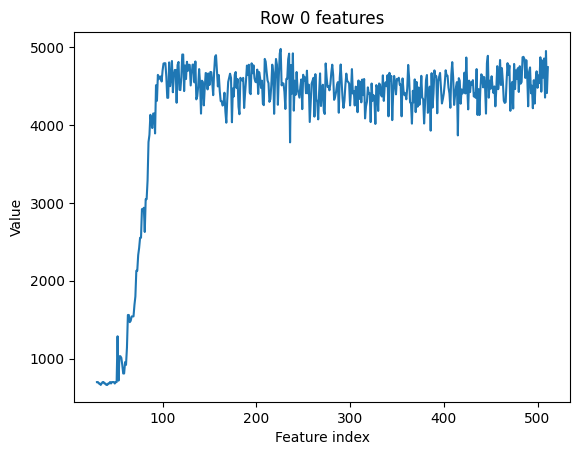

In [3]:
#Hvordan man plotter en feature? (Måske er det nydvendigt senere)
df_numeric = df.apply(pd.to_numeric, errors="coerce")

plt.plot(df_numeric.iloc[30:, 0])  # Plot the first feature (column index 0) for all rows except the header
plt.xlabel("Feature index")
plt.ylabel("Value")
plt.title("Row 0 features")
plt.show()

#Transformer configuration 
- Config : Gets the  configuration of the pretrained model, in our case bert, which is from huggingface
- Model : generates the model from the configuration, initialized with randomized weights

The config, defines the following:
- hidden size : size of the vector used to represent each token inside the model. So the size of how many numbers should represent a token/word, and that becomes a vector. Must be divisible by number of heads. 

- number of layers : Number of transformer blocks stacked on top of eachother. Contains mult head layer connections. 12 layers. 

- number of attention heads : The amount of attention heads running in parralel. So each head would focus on different attention pattern (Long term relation, grammar, closely-related, etc.)

- intermediate size : hidden size of the feedforward network inside each tranformer network. Each layer has a small neural network. 
    - linear layer -> Activation function -> Linear layer
    - Often size = 4 * hidden size?

- dropout values : Regularization technique. Randomly turns of a percentage of random neurons. 

- vocabulary size : How many unqiue tokens a language knows. 

- positional embedding length : Defines maximum sequence length. So a model can only process at most x amount of tokens at once. Each position has a vector. For time series models this corresponds to max window size (sequence length).
    - final embedding = token embedding + positional embedding.




In [ ]:
criterion = nn.CrossEntropyLoss()

model = CNNTransformer()

X = torch.tensor(df_numeric.values, dtype=torch.float32)  # shape: (num_samples, 1, num_features)
y = torch.

logits = model(X)    # shape: (batch_size, num_classes)

labels = torch.tensor([0], dtype=torch.long)  # Example label for a single sample

loss = criterion(logits, labels)